In [361]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
import warnings 
warnings.filterwarnings('ignore')

In [362]:
# load the data set 
df = pd.DataFrame(sns.load_dataset('titanic'))   

In [363]:
# check the data type of the all columns 
df.dtypes

survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object

In [364]:
df.shape

(891, 15)

In [365]:
# checking the duplicated value in the data
df.duplicated().sum()

np.int64(107)

In [366]:
# drop the duplicates value  
df.drop_duplicates(inplace=True)

In [367]:
df.reset_index(drop=True , inplace=True)

In [368]:
# it shows the top 5 first data automatically 
df.head() 

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [369]:
# it shows the bottom five data from the data
df.tail()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
779,0,3,female,39.0,0,5,29.125,Q,Third,woman,False,NaN,Queenstown,no,False
780,1,1,female,19.0,0,0,30.000,S,First,woman,False,B,Southampton,yes,True
781,0,3,female,NaN,1,2,23.450,S,Third,woman,False,NaN,Southampton,no,False
782,1,1,male,26.0,0,0,30.000,C,First,man,True,C,Cherbourg,yes,True
783,0,3,male,32.0,0,0,7.750,Q,Third,man,True,NaN,Queenstown,no,True


In [370]:
# it shows the all the null value from the data 
df.isnull().sum()

survived         0
pclass           0
sex              0
age            106
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           582
embark_town      2
alive            0
alone            0
dtype: int64

In [371]:
# it shows the numeric columns data only like mean,median,min,max
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,784.000000,784.000000,678.000000,784.000000,784.000000,784.000000
mean,0.411990,2.243622,29.869351,0.522959,0.415816,34.711740
std,0.492507,0.855056,14.759076,0.986231,0.836922,52.160151
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,20.000000,0.000000,0.000000,8.050000
50%,0.000000,3.000000,28.250000,0.000000,0.000000,15.900000
75%,1.000000,3.000000,39.000000,1.000000,1.000000,34.109350
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [326]:
# EDA >> Exploratory data analysis

In [327]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
779,0,3,female,39.0,0,5,29.1250,Q,Third,woman,False,NaN,Queenstown,no,False
780,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
781,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
782,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [328]:
# as we can see that survived and alive both the column shows the same data then we can drop one of them
df['survived'] = df.survived.replace(0,"Dead").replace(1,"Alive")

In [329]:
# it drop the column and inplace will automatically save the change in the original data set
df.drop('alive' , axis=1,inplace=True)

In [330]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alone'],
      dtype='object')

In [331]:
# seprated the string columns and numerical columns 
String_column = [feature for feature in df if df[feature].dtype == "O"]

In [332]:
String_column

['survived', 'sex', 'embarked', 'who', 'embark_town']

In [333]:
numerical_columns = [feature for feature in df if df[feature].dtype != 'O']

In [334]:
numerical_columns

['pclass',
 'age',
 'sibsp',
 'parch',
 'fare',
 'class',
 'adult_male',
 'deck',
 'alone']

In [335]:
df['adult_male']=df.adult_male.replace(True,"Adult").replace(False,"Minor")

In [336]:
# Q1. Give the total number of the people alive or dead 
df['survived'].groupby(df['sex']).value_counts()

sex     survived
female  Alive       217
        Dead         76
male    Dead        385
        Alive       106
Name: count, dtype: int64

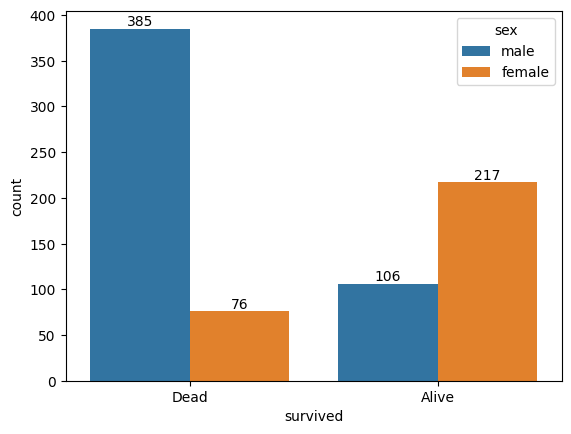

In [337]:
ax= sns.countplot( x= 'survived' , hue='sex', data=df)
for bar in ax.containers: # show label
    ax.bar_label(bar)

In [ ]:
# from the above graph we can easily understand that the maximum number of people died is Male

In [338]:
# Q2. Give the total Number of people Dead from each class
asd = df[df['survived']=="Dead"].groupby('class').agg({'pclass':'count'})

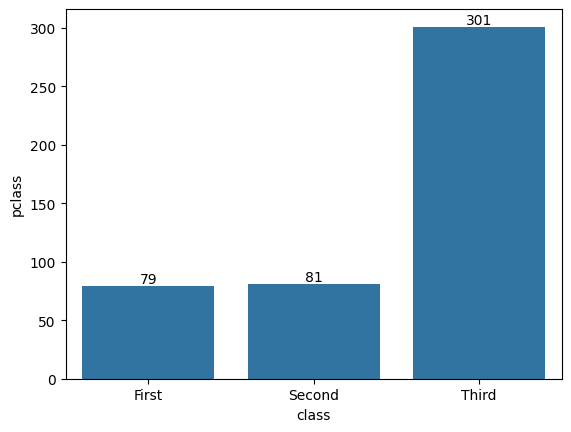

In [339]:
asb=sns.barplot(x='class',y='pclass',data=asd)
for bar in asb.containers:
    asb.bar_label(bar)

In [ ]:
# In the titanic ship crash maximum number of people died is travelled in 3rd Class 

In [340]:
# Q3. Give the total Number of people Alive from each class
aaa = df[df['survived']=="Alive"].groupby('class').agg({'pclass':'count'})

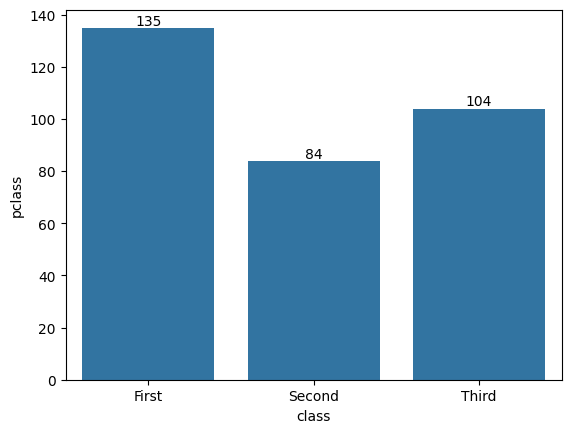

In [341]:
asa=sns.barplot(x='class',y='pclass',data=aaa)
for bar in asa.containers:
    asa.bar_label(bar)

In [ ]:
# In the titanic ship crash maximum number of Alive people is travelled in 1st Class 

In [342]:
# Q4. Give the total number of people travelled in each class 
tc = df.groupby('class').agg({'pclass':'count'})

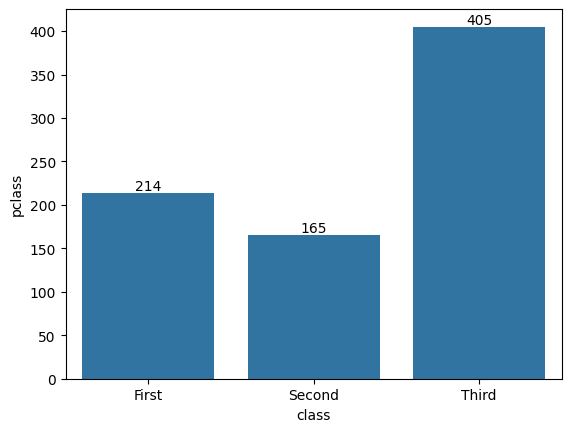

In [343]:
tcc = sns.barplot(x='class',y='pclass',data=tc)
for bar in tcc.containers:
    tcc.bar_label(bar)

In [ ]:
# maximum number people is travelled in 3rd Class

In [344]:
# Q5. Show the total fare collected from the ship on the basic of Ship class
acd = df.groupby('class').agg({'fare':'sum'})

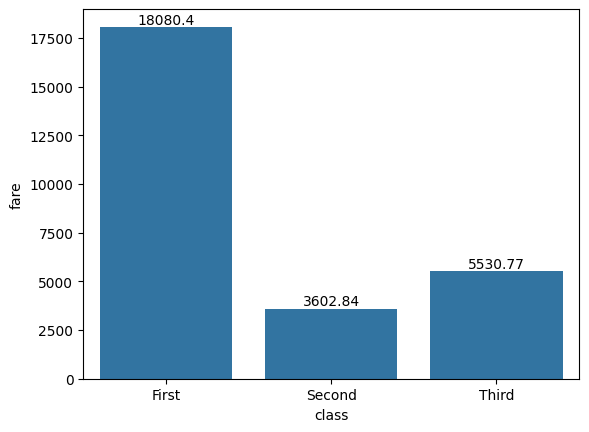

In [345]:
fare_plot = sns.barplot(x='class' , y='fare' , data=acd)
for bar in fare_plot.containers:
    fare_plot.bar_label(bar)

In [ ]:
# maximum fare was collected from the 1st Class 

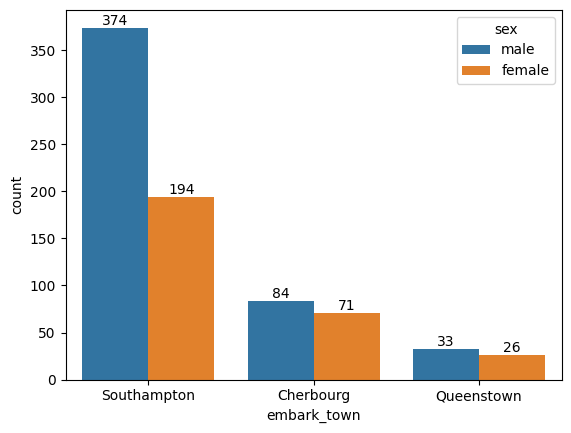

In [ ]:
# Q6. Give the details of the passenger embarked from which city 
abc = sns.countplot(x=df['embark_town'] , hue=df['sex'])
for bar in abc.containers:
    abc.bar_label(bar)

In [ ]:
# Maximum of the people at the ship was boarded from the Southampton

In [350]:
# Q7. show the total fare collected from passenger and categorised on the basic of Sex
ab = df.groupby('sex').agg({'fare':'sum'})

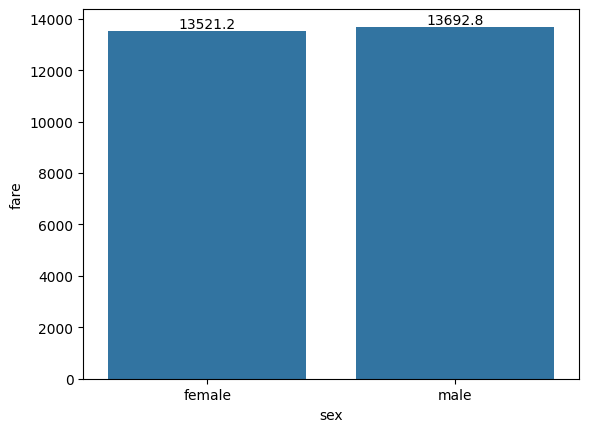

In [354]:
aa = sns.barplot( x='sex', y='fare',data=ab)
for bar in aa.containers :
    aa.bar_label(bar)

In [352]:
# Q8. How many adult male died in the ship 
srr = df[df['survived']=="Dead"].groupby('adult_male').agg({'survived':'count'})

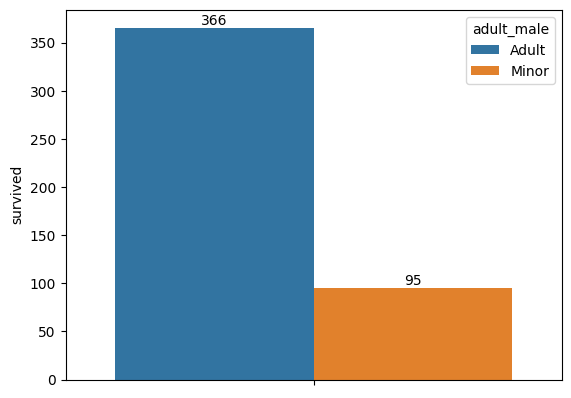

In [288]:
aqs = sns.barplot(y='survived', hue='adult_male',data=srr)
for bar in aqs.containers:
    aqs.bar_label(bar)


In [374]:
# Above graph show that the number of adult or non-adult(less than 18 year) people died at the ship